In [1]:
!pip install albumentations
!pip install selectivesearch
!pip uninstall opencv-contrib-python opencv-python
!pip install opencv-contrib-python
!pip install opencv-contrib-python --upgrade
from IPython.display import clear_output
clear_output(wait=True)

Found existing installation: opencv-contrib-python 4.10.0.84
Uninstalling opencv-contrib-python-4.10.0.84:
  Would remove:
    /usr/local/lib/python3.10/dist-packages/cv2/*
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python-4.10.0.84.dist-info/*
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Core-e6d3f451.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Gui-5dea4132.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Test-d435aae7.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5Widgets-e392eaf8.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libQt5XcbQpa-3bf8a55a.so.5.15.13
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libX11-xcb-0e257303.so.1.0.0
    /usr/local/lib/python3.10/dist-packages/opencv_contrib_python.libs/libXau-00ec42fe.so.6.0.0
    /usr/local/lib/python3.10

In [30]:
!unzip '/content/Potholes.zip' -d '/content/'
# !unzip '/content/test_proposals.zip' -d '/content/'

Archive:  /content/Potholes.zip
   creating: /content/Potholes/
  inflating: /content/__MACOSX/._Potholes  
  inflating: /content/Potholes/.DS_Store  
  inflating: /content/__MACOSX/Potholes/._.DS_Store  
  inflating: /content/Potholes/splits.json  
  inflating: /content/__MACOSX/Potholes/._splits.json  
   creating: /content/Potholes/annotated-images/
  inflating: /content/__MACOSX/Potholes/._annotated-images  
  inflating: /content/Potholes/README.md  
  inflating: /content/__MACOSX/Potholes/._README.md  
  inflating: /content/Potholes/annotated-images/img-238.jpg  
  inflating: /content/__MACOSX/Potholes/annotated-images/._img-238.jpg  
  inflating: /content/Potholes/annotated-images/img-589.xml  
  inflating: /content/__MACOSX/Potholes/annotated-images/._img-589.xml  
  inflating: /content/Potholes/annotated-images/img-210.jpg  
  inflating: /content/__MACOSX/Potholes/annotated-images/._img-210.jpg  
  inflating: /content/Potholes/annotated-images/img-576.jpg  
  inflating: /conten

In [31]:
import albumentations as A
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import sys
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
from tqdm import tqdm
import selectivesearch
import pickle
import random

current_dir = os.getcwd()
print(current_dir)
sys.path.append(current_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/content


In [32]:
class ProposalGenerator:
    def __init__(self):
        pass

    def selective_search_fast(self, image):
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Compute selective search proposals
        ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        ss.setBaseImage(image_rgb)
        ss.switchToSelectiveSearchFast()  # Use fast mode

        # Get proposals
        boxes = ss.process()

        # Convert to [x1, y1, x2, y2] format
        proposals = []
        for x, y, w, h in boxes:
            proposals.append([x, y, x+w, y+h])

        return proposals[:3000]

    def edge_boxes(self, image, max_boxes=3000, min_score=0.01):

        # Convert to RGB if necessary
        if len(image.shape) == 3 and image.shape[2] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image_rgb = image

        # Create edge boxes detector
        edge_boxes = cv2.ximgproc.createEdgeBoxes()
        edge_boxes.setMaxBoxes(max_boxes)
        edge_boxes.setMinScore(min_score)

        # Detect edges using Canny
        edges = cv2.Canny(image_rgb, 50, 150)
        edges = edges.astype(np.float32)  # Convert edge map to CV_32F
        orientation_map = np.zeros_like(edges, dtype=np.float32)  # Placeholder orientation map

        # Get bounding boxes
        boxes = edge_boxes.getBoundingBoxes(edges, orientation_map)[0]

        #Convert to [x1, y1, x2, y2] format and scale back
        proposals = []
        for box in boxes:
            x, y, w, h = box
            x = int(x)
            y = int(y)
            w = int(w)
            h = int(h)
            proposals.append([x, y, x+w, y+h])

        return proposals[:3000]

In [33]:
import json

splits = json.load(open('/content/Potholes/splits.json'))

train_files = splits['train']
test_files = splits['test']

In [48]:
!rm -rf test_proposals/

In [49]:
data_dir = '/content/Potholes/annotated-images'

class ImageProcessor:
    def __init__(self, files, proposal_generator, transform = None, size = (256, 256)):
        self.files = files
        self.proposal_generator = proposal_generator
        self.transform = transform
        self.size = size


    def generate_proposals(self, image, gt_boxes):
        proposals = self.proposal_generator(image)
        proposals = self.assign_labels(proposals, gt_boxes)

        return proposals

    def resize_gt_boxes(self, gt_boxes, scale):
        x_scale, y_scale = scale
        gt_boxes = [(x1 * x_scale, y1 * y_scale, x2 * x_scale, y2 * y_scale, c) for x1, y1, x2, y2, c in gt_boxes]
        return gt_boxes

    def assign_labels(self, proposals, gt_boxes, positive_iou_threshold=0.5, negative_iou_threshold=0.1):
      new_proposals = []
      for proposal in proposals:
          max_iou = 0.0
          assigned_label = 0  # Background class
          for gt_box in gt_boxes:
              iou = self.calculate_iou(proposal, gt_box)
              if iou > max_iou:
                  max_iou = iou
                  if iou >= positive_iou_threshold:
                      assigned_label = 1  # Object class label (assuming single class)
          if max_iou >= positive_iou_threshold or max_iou <= negative_iou_threshold:
              new_proposals.append([proposal[0], proposal[1], proposal[2], proposal[3], assigned_label])
          else:
              continue
              # Ignored sample
      return new_proposals

    def calculate_iou(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection
        return intersection / union if union > 0 else 0

    def read_label_content(self, label_path):
        tree = ET.parse(label_path)
        root = tree.getroot()

        valid_boxes = []
        filename = root.find('filename').text
        for boxes in root.iter('object'):
            label = boxes.find("name").text
            ymin = int(boxes.find("bndbox/ymin").text)
            xmin = int(boxes.find("bndbox/xmin").text)
            ymax = int(boxes.find("bndbox/ymax").text)
            xmax = int(boxes.find("bndbox/xmax").text)

            # Check if the bounding box is valid
            # img-415 has a bug in the xml file
            # xmin = xmax.......
            # Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]
            if xmin >= xmax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                xmin = xmax - 1
            if ymin >= ymax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                ymin = ymax - 1

            valid_boxes.append([xmin, ymin, xmax, ymax, 1 if label == 'pothole' else 0])

        return valid_boxes, filename

    def process_image(self, idx):
        filename = os.path.splitext(self.files[idx])[0]
        image_path = os.path.join(data_dir, f'{filename}.jpg')
        label_path = os.path.join(data_dir, f'{filename}.xml')

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        gt_boxes, _ = self.read_label_content(label_path)
        if self.transform:
            transformed = self.transform(image=image, bboxes=gt_boxes)
            image = transformed['image']
            gt_boxes = transformed['bboxes']
        else:
            scale = (self.size[1] / image.shape[1], self.size[0] / image.shape[0])
            image = cv2.resize(image, self.size)
            gt_boxes = self.resize_gt_boxes(gt_boxes, scale)
        proposals = self.generate_proposals(image, gt_boxes)

        return {
            'filename': filename,
            'image': image,
            'image_path': image_path,
            'gt_boxes': gt_boxes,
            'proposals': proposals,
        }

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return self.process_image(idx)

def precompute_proposals_and_labels(image_processor, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for image_data in tqdm(image_processor):
        filename = image_data['filename']
        proposals = image_data['proposals']
        pos = [p for p in proposals if p[4] == 1]
        if len(pos) == 0:
            print(f'{filename} no positive proposal, ignore it')
            continue
        with open(os.path.join(output_dir, f'samples_{filename}.pkl'), 'wb') as f:
            pickle.dump(image_data, f)

size = 256
transform = A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=0.3),
    ],
    bbox_params=A.BboxParams(format='pascal_voc'),
)

train_processor = ImageProcessor(train_files, ProposalGenerator().selective_search_fast, transform=transform)
precompute_proposals_and_labels(train_processor, '/content/test_proposals')
test_processor = ImageProcessor(test_files, ProposalGenerator().selective_search_fast)
precompute_proposals_and_labels(test_processor, '/content/test_proposals')

 16%|█▌        | 84/532 [00:49<03:56,  1.90it/s]

img-129 no positive proposal, ignore it


 17%|█▋        | 90/532 [00:52<04:49,  1.53it/s]

img-45 no positive proposal, ignore it


 36%|███▌      | 192/532 [01:50<02:57,  1.91it/s]

...

 59%|█████▊    | 78/133 [00:43<00:27,  2.01it/s]

img-117 no positive proposal, ignore it


 74%|███████▍  | 99/133 [00:54<00:17,  1.98it/s]

img-25 no positive proposal, ignore it


100%|██████████| 133/133 [01:13<00:00,  1.82it/s]


In [46]:
# !zip -r /content/test_proposals.zip /content/test_proposals


  adding: content/test_proposals/ (stored 0%)
  adding: content/test_proposals/samples_img-243.pkl (deflated 41%)
  adding: content/test_proposals/samples_img-92.pkl (deflated 37%)
  adding: content/test_proposals/samples_img-198.pkl (deflated 36%)
  adding: content/test_proposals/samples_img-4.pkl (deflated 35%)
  adding: content/test_proposals/samples_img-471.pkl (deflated 24%)
  adding: content/test_proposals/samples_img-259.pkl (deflated 26%)
  adding: content/test_proposals/samples_img-272.pkl (deflated 29%)
  adding: content/test_proposals/samples_img-199.pkl (deflated 43%)
  adding: content/test_proposals/samples_img-116.pkl (deflated 37%)
  adding: content/test_proposals/samples_img-466.pkl (deflated 37%)
  adding: content/test_proposals/samples_img-150.pkl (deflated 38%)
  adding: content/test_proposals/samples_img-248.pkl (deflated 46%)
  adding: content/test_proposals/samples_img-54.pkl (deflated 34%)
  adding: content/test_proposals/samples_img-664.pkl (deflated 29%)
  addi

In [84]:
import re
POSITIVE_RATE = 0.25
class ProposalDataset(torch.utils.data.Dataset):
    def __init__(self, files, samples_dir, num_samples = 30):
        self.samples = []
        self.num_samples = num_samples

        self.sample_files = []
        all_files = os.listdir(samples_dir)
        for filename in files:
            file_id = os.path.splitext(filename)[0]
            regex = re.compile(f"samples_{re.escape(file_id)}*\.pkl$")
            for filename in all_files:
                if regex.match(filename):
                    self.sample_files.append(os.path.join(samples_dir, filename))


    def __len__(self):
        return len(self.sample_files)

    def __getitem__(self, idx):
        sample_file = self.sample_files[idx]

        sample = pickle.load(open(sample_file, 'rb'))
        # image_path = sample['image_path']
        image = sample['image']
        # gt_boxes = np.ones((len(sample['gt_boxes']), 5))
        gt_boxes = sample['gt_boxes']

        proposals = sample['proposals']
        positives = [p for p in proposals if p[4] == 1]
        negatives = [p for p in proposals if p[4] == 0]
        num_pos_sample = int(self.num_samples * POSITIVE_RATE)
        sampled_positives = random.sample(positives, min(len(positives), num_pos_sample))
        actual_pos_count = len(sampled_positives)
        if actual_pos_count < num_pos_sample:
            total_recalculated = int((self.num_samples - actual_pos_count) / (1 - POSITIVE_RATE))
            num_neg_sample = total_recalculated - actual_pos_count
        else:
            num_neg_sample = self.num_samples - num_pos_sample
        sampled_negatives = random.sample(negatives, min(len(negatives), num_neg_sample))
        sampled_proposals = sampled_positives + sampled_negatives
        random.shuffle(sampled_proposals)

        image = torch.tensor(sample['image'], dtype=torch.int)
        proposals = torch.tensor(np.array(sampled_proposals), dtype=torch.float)
        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float)
        # print(transformed)
        return image, gt_boxes, proposals

def custom_collate_fn(batch):
    return tuple(zip(*batch))

batch_size = 10
trainset = ProposalDataset(files=train_files, samples_dir='./test_proposals')

valid_idx = int(len(test_files) / 2)
validset = ProposalDataset(files=test_files[:valid_idx], samples_dir='./test_proposals')
testset = ProposalDataset(files=test_files[valid_idx:], samples_dir='./test_proposals')

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
valid_loader = DataLoader(validset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)


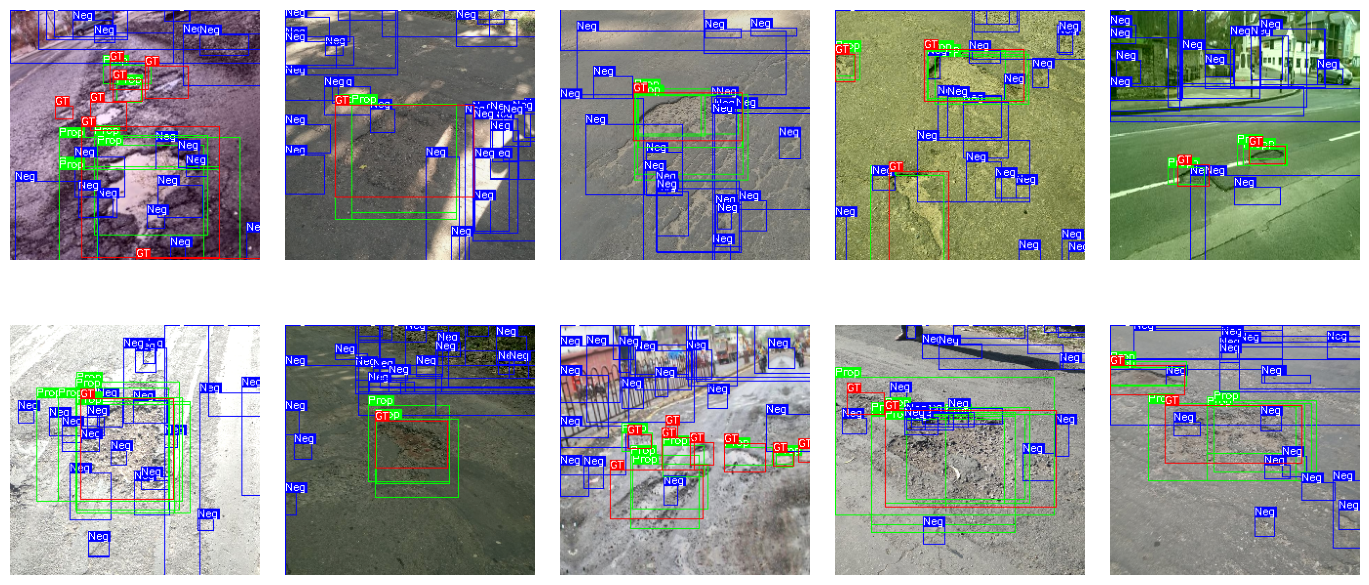

In [85]:
TEXT_COLOR = (255, 255, 255) # White
GREEN_COLOR = (0, 255, 0) # GREEN
BLUE_COLOR = (0, 0, 255) # BLUE
RED_COLOR = (255, 0, 0) # RED

def visualize_bbox(img, bbox, class_name, color=RED_COLOR, thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = bbox
    x_min, x_max, y_min, y_max = int(x_min), int(x_max), int(y_min), int(y_max)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), color, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, y_min - int(0.3 * text_height)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img

def visualize_proposals(img, ground_truth_boxes, proposals):
    img = img.copy()
    for proposal in proposals:
        box = proposal[:4]
        class_name = 'Prop' if proposal[4] == 1 else 'Neg'
        img = visualize_bbox(img, box, class_name, color=GREEN_COLOR if proposal[4] == 1 else BLUE_COLOR, thickness=1)
    for gt_box in ground_truth_boxes:
        img = visualize_bbox(img, gt_box[:4], 'GT', thickness=1)
    return img

images, gt_boxes, proposals = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

for i in range(10):
    img = visualize_proposals(images[i].numpy(), gt_boxes[i].numpy(), proposals[i].numpy())
    axes[i].imshow(img)
    axes[i].axis('off')

plt.subplots_adjust(
    left=0.05,   # Adjust the left margin
    right=0.95,  # Adjust the right margin
    top=0.95,    # Adjust the top margin
    bottom=0.05, # Adjust the bottom margin
    wspace=0.1,  # Adjust the width space between subplots
    hspace=0.001   # Adjust the height space between subplots
)
plt.show()

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torchvision.ops as ops

print(device)
class VGG16Fast(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # remove last 2 layers
        # use resnet as our backbone
        resnet = vgg16 = models.vgg16(pretrained=True)
        modules = vgg16.features
        self.backbone = nn.Sequential(*modules)
        # 13 convolutional layers and 5 max-pooling layers. stride is 2^5
        self.roi_pool = ops.RoIAlign(output_size=(7, 7), spatial_scale=1/32, sampling_ratio = 2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

    def forward(self, images, proposals):
        # proposals: List of Tensors, each of shape [num_proposals_i, 5] (x1, y1, x2, y2, class)
        # Permute the dimensions of the input image tensor
        #  from [batch_size, H, W, C] to [batch_size, C, H, W]
        images = images.permute(0, 3, 1, 2)
        batch_size = images.size(0)
        device = images.device

        # Compute feature maps
        feature_maps = self.backbone(images)
        # feature_maps shape: [batch_size, 512, H', W']

        # Prepare proposals for RoI pooling
        roi_pooling_boxes = []
        labels = []
        for i in range(batch_size):
            boxes = proposals[i][:, :4]  # Extract coordinates
            labels.append(proposals[i][:, 4].long().to(device))  # Extract labels
            # Add batch index
            indices = torch.full((boxes.shape[0], 1), i, dtype=boxes.dtype, device=device)
            roi_boxes = torch.cat([indices, boxes], dim=1)  # Shape: [num_proposals_i, 5]
            roi_pooling_boxes.append(roi_boxes)
        roi_pooling_boxes = torch.cat(roi_pooling_boxes, dim=0)  # Shape: [total_num_proposals, 5]

        pooled_features = self.roi_pool(feature_maps, roi_pooling_boxes)
        # pooled_features shape: [total_num_proposals, 512, 7, 7]

        logits = self.classifier(pooled_features)
        # logits shape: [total_num_proposals, num_classes]

        labels = torch.cat(labels, dim=0)

        return logits, labels


cuda


In [90]:
def train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=20):
    # Lists to store loss and accuracy
    train_losses = []
    val_accuracies = []

    best_accuracy = 0.0  # For saving the best model

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for images, gt_boxes_list, proposals_list in train_loader:
            images = torch.stack(images).type(torch.float32).to(device) / 255.0   # [batch_size, 3, H, W]

            proposals = [props.to(device) for props in proposals_list]
            logits, labels = model(images, proposals)

            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

        epoch_loss = running_loss / total_samples
        train_losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, gt_boxes_list, proposals_list in valid_loader:
                images = torch.stack(images).type(torch.float32).to(device) / 255.0
                proposals = [props.to(device) for props in proposals_list]

                logits, labels = model(images, proposals)
                _, preds = torch.max(logits, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        accuracy = 100 * correct / total
        val_accuracies.append(accuracy)
        print(f"Validation Accuracy: {accuracy:.2f}%")

        # # Save the model if validation accuracy improves
        # if accuracy > best_accuracy:
        #     best_accuracy = accuracy
        #     torch.save(model.state_dict(), 'best_model.pth')
        #     print("Model saved!")

        model.train()

    # Plotting the loss and accuracy
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(12, 5))

    # Plot training loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
    plt.title('Validation Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Loss: 0.4143
Validation Accuracy: 82.22%
Epoch [2/20], Loss: 0.2917
Validation Accuracy: 88.59%
Epoch [3/20], Loss: 0.2075
Validation Accuracy: 91.58%
Epoch [4/20], Loss: 0.1605
Validation Accuracy: 94.23%
Epoch [5/20], Loss: 0.1312
Validation Accuracy: 96.07%
Epoch [6/20], Loss: 0.1114
Validation Accuracy: 95.61%
Epoch [7/20], Loss: 0.0918
Validation Accuracy: 96.16%
Epoch [8/20], Loss: 0.0818
Validation Accuracy: 96.14%
Epoch [9/20], Loss: 0.0785
Validation Accuracy: 96.67%
Epoch [10/20], Loss: 0.0650
Validation Accuracy: 96.36%
Epoch [11/20], Loss: 0.0596
Validation Accuracy: 96.53%
Epoch [12/20], Loss: 0.0532
Validation Accuracy: 96.84%
Epoch [13/20], Loss: 0.0447
Validation Accuracy: 96.81%
Epoch [14/20], Loss: 0.0400
Validation Accuracy: 96.84%
Epoch [15/20], Loss: 0.0421
Validation Accuracy: 96.43%
Epoch [16/20], Loss: 0.0361
Validation Accuracy: 97.18%
Epoch [17/20], Loss: 0.0341
Validation Accuracy: 96.86%
Epoch [18/20], Loss: 0.0292
Validation Accuracy: 96.94%
E

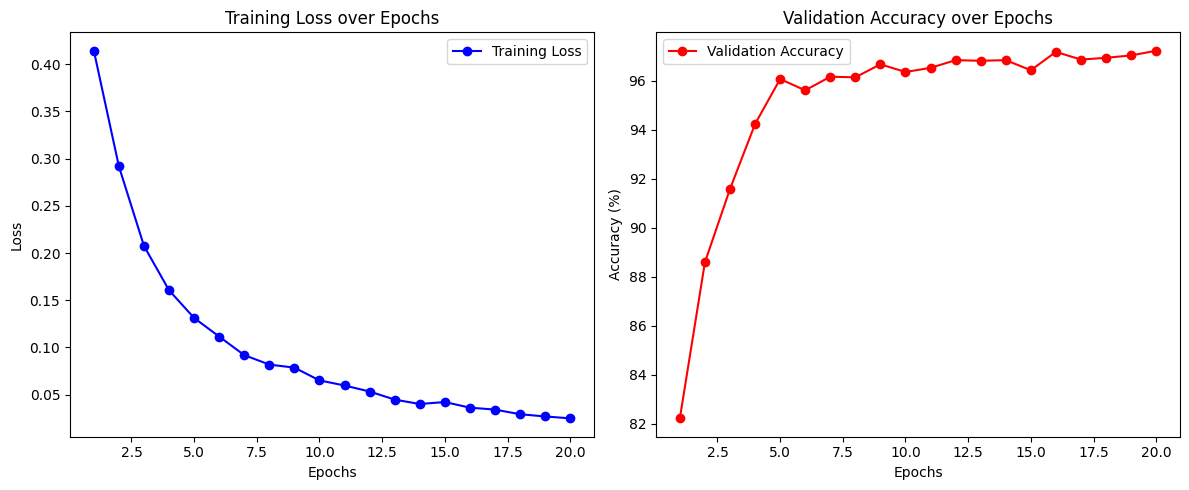

In [91]:
criterion = nn.CrossEntropyLoss()
vgg_fast = VGG16Fast().to(device)
optimizer = optim.SGD(vgg_fast.parameters(), lr=0.001, momentum=0.9)
train(vgg_fast, train_loader, valid_loader, criterion, optimizer, num_epochs=20)

In [95]:
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    val_accuracies = []
    with torch.no_grad():
        for images, gt_boxes_list, proposals_list in valid_loader:
            images = torch.stack(images).type(torch.float32).to(device) / 255.0
            proposals = [props.to(device) for props in proposals_list]

            logits, labels = model(images, proposals)
            _, preds = torch.max(logits, 1)
            scores = torch.softmax(logits, dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)
    print(f"Validation Accuracy: {accuracy:.2f}%")

test(vgg_fast, test_loader)

def nms(boxes, scores, threshold=0.7):
    score_boxes = torch.cat([scores, boxes], dim=1)
    sorted_boxes = score_boxes[torch.argsort(score_boxes[:, 0], descending=True)]
    print(sorted_boxes)


tensor([[1.0000e+00, 8.3645e-13],
        [9.7267e-01, 2.7331e-02],
        [9.9999e-01, 9.2373e-06],
        [9.9924e-01, 7.5850e-04],
        [5.4574e-01, 4.5426e-01],
        [9.6406e-01, 3.5935e-02],
        [9.9901e-01, 9.9291e-04],
        [9.8795e-01, 1.2053e-02],
        [9.9557e-01, 4.4286e-03],
        [9.4932e-01, 5.0684e-02],
        [1.0000e+00, 1.9475e-10],
        [9.9558e-01, 4.4209e-03],
        [9.9993e-01, 6.7604e-05],
        [8.6602e-01, 1.3398e-01],
        [1.0000e+00, 2.6085e-10],
        [6.4897e-01, 3.5103e-01],
        [3.7760e-02, 9.6224e-01],
        [4.1234e-01, 5.8766e-01],
        [9.9976e-01, 2.4076e-04],
        [9.9995e-01, 4.8586e-05],
        [9.9952e-01, 4.7884e-04],
        [9.9808e-01, 1.9197e-03],
        [9.9997e-01, 2.7789e-05],
        [8.7170e-01, 1.2830e-01],
        [9.9988e-01, 1.2413e-04],
        [1.0000e+00, 2.2676e-10],
        [5.2780e-02, 9.4722e-01],
        [9.9991e-01, 8.9418e-05],
        [8.8251e-01, 1.1749e-01],
        [9.998